In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

In [2]:
# Definir la función f(x, y)
def f(x, y):
    return np.sin(x) * np.cos(y) + (x**2 + y**2) / 10

# Gradiente de f(x, y)
def grad_f(x, y):
    df_dx = np.cos(x) * np.cos(y) + (2*x) / 10
    df_dy = -np.sin(x) * np.sin(y) + (2*y) / 10
    return np.array([df_dx, df_dy])

# Crear una malla de valores para graficar la superficie
x_vals = np.linspace(-3, 3, 50)
y_vals = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)

In [3]:
# Parámetros del algoritmo de gradiente
learning_rate = 0.2
tol = 1e-6
max_iter = 50

# Inicializar listas para almacenar los recorridos
x_traj_min, y_traj_min, z_traj_min = [], [], []
x_traj_max, y_traj_max, z_traj_max = [], [], []

# **Gradiente Descendente** (mínimos)
x_min, y_min = np.array([-2, 2])  # Punto inicial
for _ in range(max_iter):
    grad = grad_f(x_min, y_min)
    if np.linalg.norm(grad) < tol:
        break
    x_min -= learning_rate * grad[0]
    y_min -= learning_rate * grad[1]
    x_traj_min.append(x_min)
    y_traj_min.append(y_min)
    z_traj_min.append(f(x_min, y_min))



In [4]:
# **Gradiente Ascendente** (máximos)
x_max, y_max = np.array([-1, 0])  # Punto inicial
for _ in range(max_iter):
    grad = grad_f(x_max, y_max)
    if np.linalg.norm(grad) < tol:
        break
    x_max += learning_rate * grad[0]
    y_max += learning_rate * grad[1]
    x_traj_max.append(x_max)
    y_traj_max.append(y_max)
    z_traj_max.append(f(x_max, y_max))


# Convertir las listas en numpy arrays
x_traj_min = np.array(x_traj_min)
y_traj_min = np.array(y_traj_min)
z_traj_min = np.array(z_traj_min)
x_traj_max = np.array(x_traj_max)
y_traj_max = np.array(y_traj_max)
z_traj_max = np.array(z_traj_max)


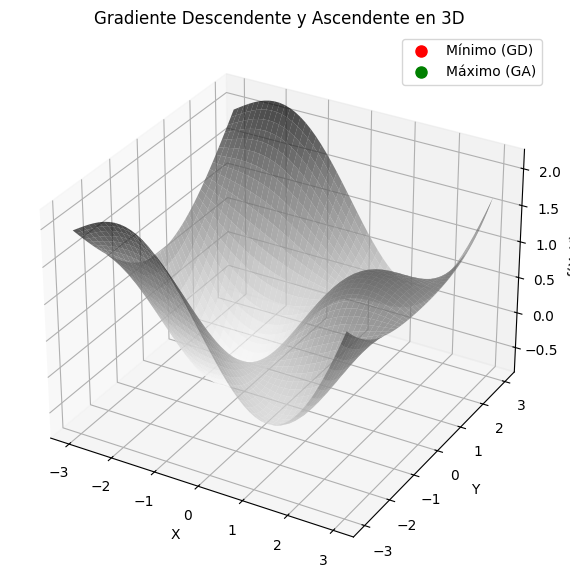

In [5]:
# **Configurar la figura en 3D**
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Graficar la superficie
ax.plot_surface(X, Y, Z, cmap="Greys", alpha=0.7)

# Agregar puntos móviles para la animación
point_min, = ax.plot([], [], [], 'ro', markersize=8, label="Mínimo (GD)")
point_max, = ax.plot([], [], [], 'go', markersize=8, label="Máximo (GA)")

# Líneas de trayectoria
path_min, = ax.plot([], [], [], 'r-', linewidth=3)
path_max, = ax.plot([], [], [], 'g-', linewidth=3)

# Etiquetas y leyenda
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("f(X, Y)")
ax.set_title("Gradiente Descendente y Ascendente en 3D")
ax.legend()


In [6]:
# **Función de actualización para la animación**
def update(frame):
    if frame < len(x_traj_min):
        point_min.set_data([x_traj_min[frame]], [y_traj_min[frame]])
        #point_min.set_3d_properties(z_traj_min[frame])
        path_min.set_data(x_traj_min[:frame+1], y_traj_min[:frame+1])
        path_min.set_3d_properties(z_traj_min[:frame+1])

    if frame < len(x_traj_max):
        point_max.set_data([x_traj_max[frame]], [y_traj_max[frame]])
        #point_max.set_3d_properties(z_traj_max[frame])
        path_max.set_data(x_traj_max[:frame+1], y_traj_max[:frame+1])
        path_max.set_3d_properties(z_traj_max[:frame+1])

    return point_min, point_max, path_min, path_max



In [7]:
# **Crear la animación**
ani = animation.FuncAnimation(fig, update, frames=max(len(x_traj_min), len(x_traj_max)), interval=50, blit=False)

# **Guardar la animación como GIF**
gif_filename = "gradiente_3d.gif"
ani.save(gif_filename, writer="pillow", fps=10)

print(f"Animación guardada como {gif_filename}")


Animación guardada como gradiente_3d.gif


In [8]:
# **Mostrar la animación**
plt.show()
